# BinX AI & ML Internship
## Week 4 — Day 3: Bias-Variance & Diagnosing Model Fit

**Topics covered:**
- Underfitting (high bias) vs. overfitting (high variance)
- The bias-variance trade-off
- Diagnosing fit from the train-vs-validation gap
- Regularization: Ridge (L2) and Lasso (L1)

---

## 1. Where I'm Starting From

Day 1 taught me how to split data honestly.
Day 2 taught me how to evaluate reliably with cross-validation.

But there's a question neither day answered:

**Once I have a reliable score — how do I know if the model is
actually learning well? And if it isn't, what exactly is wrong?**

A validation F1 of 0.60 could mean two very different things:

```text
Scenario A:  Train F1 = 0.61  →  model too simple, learns nothing useful
Scenario B:  Train F1 = 0.99  →  model memorized training data, fails to generalize
```

Same validation score. Completely different problems. Completely different fixes.

Today is about learning to tell the difference — and knowing what to do about it.

---

## 2. What Is Model Fit?

When a model trains, it tries to learn the relationship between
features and the target. But there are three ways this can go:

```text
The model didn't learn enough            →  Underfitting
The model learned the real pattern       →  Good Fit
The model memorized the training data    →  Overfitting
```

Each has a distinct signature in the numbers — and a different fix.

A useful visual intuition:

```text
Underfitting             Good Fit              Overfitting
(too simple)             (just right)          (too complex)

  •   •                   •   •                 •╮
-       •               •   ╭─╮   •           ╰──•╮
  •   •               •   ╰───╯   •                ╰•
              ─────── captures the pattern ─────────────▶
              model passes through noise too
```

The goal is always the middle column.

---

## 3. Underfitting — High Bias

**What it is:**
The model is too simple to capture the real pattern in the data.
It makes poor predictions not just on new data, but on the
training data it was given.

**What the numbers look like:**
```text
Train F1  = 0.58
Val F1    = 0.55
Gap       ≈ 0
```

Both scores are low. The small gap isn't a sign of good
generalization — it means the model is equally bad everywhere.

**Important distinction:**
A small gap alone is not evidence of a good model.
Consistently bad is still bad.

---

## 4. Causes of Underfitting

Underfitting can happen for several distinct reasons —
and the right fix depends on which cause is at work.

**1. Model complexity too low**
The model's structure can't represent the real pattern.
A Decision Tree with `max_depth=1` can only ask one yes/no question —
rarely enough for a real problem.

```text
Too simple model  →  misses real patterns  →  high bias
```

**2. Weak or missing features**
Even a powerful model underfits if the input information is poor.
Predicting diabetes from Age and Pregnancies alone — when Glucose,
BMI, and BloodPressure are the real drivers — will underfit regardless
of model complexity.

```text
Irrelevant features  →  model has nothing to learn from  →  underfitting
```

**3. Regularization too strong**
Regularization discourages complexity. But if alpha is very large,
the penalty dominates — the model is forced toward zero weights and
predicts only the mean. That's underfitting induced by over-penalization.

```text
alpha very large  →  all weights zeroed  →  model predicts mean only  →  underfitting
```

**4. Insufficient training (for iterative models)**
Applies mainly to gradient-based models (Neural Networks, Gradient Boosting)
that learn over multiple passes (epochs). Stopping too early means the model
hasn't had time to find the pattern.

```text
Early stopping too aggressive  →  model hasn't converged  →  underfitting
```

Note: Decision Trees don't train iteratively, so this cause
doesn't apply to today's experiments. It becomes relevant
when working with Neural Networks.

**The fix depends on the cause:**

| Cause | Fix |
|-------|-----|
| Model too simple | Use a more complex model |
| Weak features | Engineer better, more informative features |
| Regularization too strong | Reduce alpha |
| Insufficient training | Train longer (iterative models only) |

---

## 5. Overfitting — High Variance

**What it is:**
The model is too complex. Instead of learning the general pattern,
it memorized the training examples — including their noise, quirks,
and outliers. It performs perfectly on training data and poorly
on anything new.

**What the numbers look like:**
```text
Train F1  = 1.00
Val F1    = 0.52
Gap       = 0.48   ← large gap is the signature
```

The gap between train and validation is the primary diagnostic.
A large gap is a strong signal of overfitting — though it should
be investigated rather than treated as absolute proof, since a gap
can also result from distribution shift between splits or
a non-representative validation set.



---

## 6.Causes of overfitting:

| Cause | Explanation |
|-------|-------------|
| Model too complex | More parameters than the data can reliably estimate |
| Too many irrelevant features | Noise features give the model spurious patterns to memorize |
| Too little training data | Easier to memorize small datasets than large ones |
| Noise and outliers | Extreme points get memorized as if they were real patterns |

**The fix:**
- Limit model complexity (reduce `max_depth`, increase `min_samples_leaf`)
- Apply regularization (Ridge or Lasso for linear models)
- Remove irrelevant features
- Collect more training data
- Clean outliers and noise

> A note on noise and outliers:
> A simple model ignores the outlier — it fits the general trend.
> An overly complex model tries to pass through every point,
> including the outlier, treating noise as signal.

---

## 7. Good Fit — The Target

**What it looks like:**
```text
Train F1  = 0.78
Val F1    = 0.76
Gap       = 0.02   ← small gap
```

High training score. High validation score. Small gap.

The model learned the real pattern and generalized it well.

**Two things to verify even when the numbers look good:**

1. Are both scores high enough to be useful for the task?
   A gap of 0.01 is great — but Train=0.55, Val=0.54 is still underfitting.

2. Is the evaluation honest?
   A single validation split could be unusually easy (Day 2).
   CV and a locked test set give more confidence.

---

## 8. The Diagnostic Table

The gap between training and validation scores is the main
diagnostic tool. Always look at both scores together — neither
alone tells the full story.

| Training Score | Validation Score | Gap | Diagnosis |
|---------------|-----------------|-----|-----------|
| Low | Low | Small | Underfitting — model too simple or features too weak |
| High | Much lower | Large | Overfitting — model memorized training data |
| High | High | Small | Good fit — this is the target |


**During model development: always diagnose from Train vs Validation.**
The test set stays locked — using it for diagnosis contaminates it,
exactly as Day 1 showed.

> **Important:** A small gap does not automatically mean a good model.
> If both scores are low, the model is still underfitting.

---

## 9. Bias and Variance

These are the two fundamental sources of model error —
and understanding them explains why every tuning decision
involves a trade-off.

**Bias — error from wrong assumptions**

A high-bias model makes oversimplified assumptions.
It misses important patterns — consistently, the same way, every time.

```text
Model too simple
      ↓
Misses real patterns
      ↓
High Bias  →  Underfitting
```

**Variance — error from sensitivity to training data**

A high-variance model is too sensitive to the specific training
samples it saw. Train it on a different random split and the
model changes dramatically.

```text
Model too complex
      ↓
Learns noise, not pattern
      ↓
High Variance  →  Overfitting
```

**The key difference:**

Bias is about being consistently wrong.
Variance is about being inconsistently right.

A biased model gives the same wrong answer regardless of
which training data it saw. A high-variance model gives
different answers depending on which specific samples it happened to get.

**Important:** bias and variance are not fixed properties of an algorithm.
They depend on the hyperparameters.

```text
Decision Tree  max_depth=1    →  High Bias   (underfitting)
Decision Tree  max_depth=None →  High Variance  (overfitting)
```

Same algorithm. Completely different behavior. The difference is complexity.

---

## 10. Irreducible Error

Not all prediction error can be fixed — regardless of how good
the model is or how much data we have.

Real data contains:
- Measurement noise (instruments aren't perfect)
- Missing information (not all relevant features were collected)
- Inherent randomness in the process

These create a floor below which no model can go.

**The full picture of prediction error:**

```text
Total Prediction Error
         │
         ├── Bias²            (fixable — better model)
         ├── Variance          (fixable — regularization, data)
         └── Irreducible Noise (cannot be fixed)
```

Or more formally:

```text
Expected Error  ≈  Bias²  +  Variance  +  Noise
```

This has a practical implication: if validation F1 plateaus
around 0.68 on the Pima dataset despite trying many models,
it may not be a modeling failure — some of the error is
irreducible given the features available.

Knowing this prevents wasting time chasing a perfect score
that the data cannot support.

---

## 11. The Bias-Variance Trade-off

As model complexity increases, bias and variance move in
opposite directions:

```text
Complexity ↑  →  Bias ↓ ,  Variance ↑
Complexity ↓  →  Bias ↑ ,  Variance ↓
```

**Training Error vs Validation Error across complexity:**

| Complexity | Training Error | Validation Error |
|-----------|---------------|-----------------|
| Very low | High | High |
| Increasing | ↓ | ↓ |
| Sweet spot | Low | Lowest |
| Very high | Very low | ↑ (starts rising) |

The goal is the sweet spot — complex enough to capture the
real pattern, simple enough to generalize.

```text
            Val F1
              │
              │        ● Sweet spot
              │      ●     ●
              │    ●           ●
              │  ●               ●  Overfitting
              │●                    (train keeps rising,
              │  Underfitting        val drops)
              └──────────────────────────────
                      max_depth →
```

**A note on score vs error:**

In this notebook I use F1 (higher = better).
Bias-variance literature typically uses Error (lower = better).
The relationship is:

```text
Higher F1  =  Lower Error
Lower  F1  =  Higher Error
```

The shapes of the curves are mirrored — the trade-off is the same.

---

## 12. A Practical Diagnostic Workflow

Before tuning anything, diagnose first.
The fix for underfitting makes overfitting worse — and vice versa.

```text
1. Train the model
         ↓
2. Calculate Train score
         ↓
3. Calculate Validation score
         ↓
4. Are both scores low?
         ├── Yes → Underfitting
         │          ↓
         │       Increase model capacity
         │       Improve / add features
         │       Reduce regularization strength
         │
         └── No
              ↓
         Is the gap large?
              ├── Yes → Overfitting
              │          ↓
              │       Reduce complexity
              │       Apply regularization
              │       Collect more data
              │       Remove noisy features
              │
              └── No
                   ↓
                Good Fit 
                   ↓
              Run CV to confirm stability
                   ↓
              Evaluate once on Test
```

**What NOT to do:**

```text
 See low validation score → immediately increase complexity
```

This is wrong because the problem might be overfitting —
where increasing complexity makes things worse, not better.
Always check the training score first to determine direction.

---

## 13. Regularization

Regularization is the standard cure for overfitting in linear models.

Without regularization, the model minimizes prediction error alone —
and can use arbitrarily large weights to do so. Large weights mean the
model is very sensitive to small changes in input (high variance).

Regularization adds a penalty term that discourages large weights:

```text
Without regularization:
  Minimize:  Prediction Error

With regularization:
  Minimize:  Prediction Error  +  α × Penalty(weights)
```

The result: the model trades a small increase in training error
for a potentially large decrease in variance — better generalization.

**The alpha parameter controls penalty strength:**

```text
α = 0    →  no regularization  →  plain regression
α small  →  weak penalty       →  slightly constrained
α large  →  strong penalty     →  heavily constrained  →  risk of underfitting
α very large  →  all weights → 0  →  model predicts mean only  →  underfitting
```

Choosing the right alpha is itself a hyperparameter tuning problem —
which GridSearchCV (Day 4) handles systematically.

**Hyperparameter vs Parameter — an important distinction:**

A **parameter** is learned by the model from the data:
weights in Linear Regression, splitting rules in Decision Tree.

A **hyperparameter** is set by us before training:
`max_depth`, `alpha`, `min_samples_leaf`, `n_estimators`.

GridSearchCV searches over hyperparameters — not parameters.

---

## 14. Model Capacity

**Model capacity** means how much complexity a model is capable
of representing.

A low-capacity model can learn only simple patterns.
A high-capacity model can represent more complex relationships.

For a Decision Tree, capacity can be controlled by parameters such as:

- `max_depth`
- `min_samples_leaf`
- `min_samples_split`

```text
Low Capacity
    ↓
Simple patterns only
    ↓
High Bias
    ↓
Underfitting

High Capacity
    ↓
Complex patterns
    ↓
Can learn noise
    ↓
High Variance
    ↓
Overfitting
```

---

## 15. Ridge vs Lasso — Math and Intuition

Both Ridge and Lasso add a regularization penalty,
but the shape of that penalty creates a fundamental difference.

**Ridge (L2):**

```text
Loss  =  Prediction Error  +  α × Σ wᵢ²
```

The penalty is the sum of squared weights.
The L2 penalty has a smooth gradient everywhere — it always
pushes weights toward zero, but the push gets weaker as
the weight gets smaller. Weights shrink but never reach exactly zero.

**Lasso (L1):**

```text
Loss  =  Prediction Error  +  α × Σ |wᵢ|
```

The penalty is the sum of absolute weights.
The L1 penalty has a constant gradient — the push toward zero
is the same regardless of how small the weight already is.
This means Lasso can push weak weights all the way to exactly zero.

**Why the zero matters:**

```text
Ridge:   5  →  3  →  1  →  0.2  →  0.04  (never zero)
Lasso:   5  →  3  →  1  →  0           (can reach zero)
```

A zero coefficient means the feature is completely excluded
from the model — Lasso performs automatic feature selection
as a side effect of regularization.

**When to use which:**

| | Ridge | Lasso |
|--|-------|-------|
| Penalty | Sum of squared weights (L2) | Sum of absolute weights (L1) |
| Effect | Shrinks toward zero | Can shrink to exactly zero |
| Feature selection | No — keeps all features | Yes — removes weak features |
| Best when | All features likely contribute | Some features likely irrelevant |

**Scaling matters:**
Both Ridge and Lasso penalize large weights.
If features have very different scales, the penalty treats them
unequally — a feature measured in thousands gets more penalty
than one measured in ones, even if it's equally important.
`StandardScaler` before Ridge/Lasso is not optional — it's required.

**Other ways to control overfitting:**

| Method | How | Best for |
|--------|-----|---------|
| Reduce complexity | Lower `max_depth`, raise `min_samples_leaf` | Tree models |
| Ridge / Lasso | Penalize large weights | Linear models |
| More training data | Harder to memorize larger datasets | Any model |
| Feature selection | Remove noisy / irrelevant features | Any model |
| Early stopping | Stop before validation score peaks | Iterative models (NN) |
| Dropout | Randomly deactivate neurons during training | Neural Networks only |

---

> **Key Terms**
>
> **Generalization:** The ability of a model to perform well on
> unseen data, not just the training data.
>
> **Memorization:** When a model learns specific training examples,
> including noise, instead of learning the general pattern.
>
> **Gap:** The difference between training and validation performance.
>
> **Noise:** Random or irrelevant variation that does not represent
> the true underlying pattern.
>
> **Outlier:** An observation that is unusually far from the rest
> of the data.
> **Bias:** Error caused by overly simple assumptions. High bias
> usually leads to underfitting.
>
> **Variance:** Error caused by a model being too sensitive to the
> specific training data. High variance usually leads to overfitting.
>
> **Sensitivity:** How strongly a model changes when the training
> data changes.
>
> **Hyperparameter:** A setting chosen by the practitioner that
> controls how the model is trained or how complex it can become.
>
> **Parameter:** A value learned by the model from the training data.
>
> **Model Complexity:** How flexible or powerful a model is in
> representing patterns in the data.

---

## 16. Putting It Into Practice

### 1. Imports Libraries

In [23]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, learning_curve, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, r2_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

SEED = 42

### 2. Load Data

Pima Indians Diabetes — 768 samples, binary classification.

The classification experiments use `Outcome` as the target.
Deep Dive B (Ridge vs Lasso) uses a regression task —
predicting `SkinThickness` — to make coefficient shrinkage visible.

In [24]:
# Define the column names
col_names = [
    "Pregnancies","Glucose","BloodPressure","SkinThickness","Insulin","BMI","DiabetesPedigreeFunction","Age", "Outcome"
]


# Load the Pima Diabetes dataset
df = pd.read_csv(
    "../../Week3/Day 3/data/pima-indians-diabetes.csv",
    header=None,
    names=col_names
)


# Check the dataset
print(f"Shape: {df.shape}")
print(f"Class balance: {df['Outcome'].mean():.1%} diabetic")
print(f"\nFeatures: {list(df.drop('Outcome', axis=1).columns)}")

Shape: (768, 9)
Class balance: 34.9% diabetic

Features: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


### 3. Train / Validation / Test Split

Same three-way split discipline from Day 1.

Today the validation set serves a specific purpose:
diagnosing model fit by comparing train vs validation scores.
The test set stays locked throughout all experiments.

In [25]:
X_cls = df.drop("Outcome", axis=1)
y_cls = df["Outcome"]

# Step 1 — lock away 20% as the final test set
X_temp, X_test, y_temp, y_test = train_test_split(
    X_cls, y_cls,
    test_size=0.2,
    random_state=SEED,
    stratify=y_cls
)

# Step 2 — split remaining 80% into 60% train / 20% validation
X_tr, X_val, y_tr, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.25,
    random_state=SEED,
    stratify=y_temp
)

print(f"Training:   {X_tr.shape[0]} rows  (60%)")
print(f"Validation: {X_val.shape[0]} rows  (20%)  ← diagnosis happens here")
print(f"Test:       {X_test.shape[0]} rows  (20%)  ← locked")

Training:   460 rows  (60%)
Validation: 154 rows  (20%)  ← diagnosis happens here
Test:       154 rows  (20%)  ← locked


### 4. Experiment 1 — Deliberate Overfitting

**Hypothesis:** A Decision Tree with no depth limit will memorize
the training data completely — perfect training score, significantly
lower validation score.

The gap between the two is the evidence of overfitting.

In [26]:
# Train an unrestricted Decision Tree
overfit_model = DecisionTreeClassifier(
    max_depth=None,
    random_state=SEED
)

overfit_model.fit(X_tr, y_tr)


# Compare performance on train and validation sets
train_f1 = f1_score(
    y_tr,
    overfit_model.predict(X_tr)
)

val_f1 = f1_score(
    y_val,
    overfit_model.predict(X_val)
)

gap = train_f1 - val_f1


print(f"Train F1:      {train_f1:.3f}")
print(f"Validation F1: {val_f1:.3f}")
print(f"Gap:           {gap:.3f}")

Train F1:      1.000
Validation F1: 0.667
Gap:           0.333


**Visualizing Overfitting**

The training score is perfect, but validation performance is much lower.

A simple visualization makes this gap easier to see.

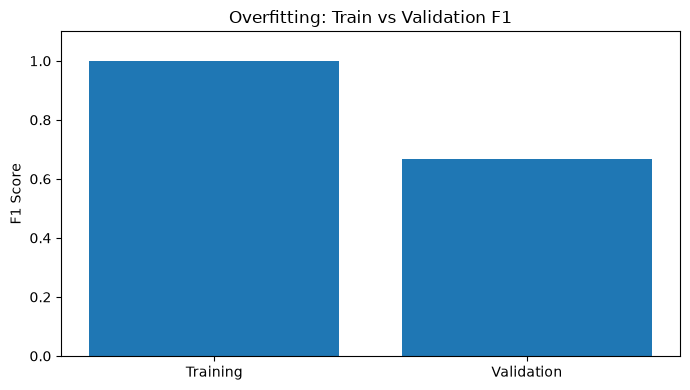

In [27]:
scores = pd.DataFrame({
    "Dataset": ["Training", "Validation"],
    "F1 Score": [train_f1, val_f1]
})

plt.figure(figsize=(7, 4))

plt.bar(scores["Dataset"], scores["F1 Score"])

plt.ylim(0, 1.1)
plt.ylabel("F1 Score")
plt.title("Overfitting: Train vs Validation F1")

plt.tight_layout()
plt.show()

**Diagnosis: Overfitting — High Variance**

Evidence from the numbers:

- Train F1 = 1.000 — every training sample was classified correctly
- Val F1   = 0.667 — performance dropped on unseen data
- Gap      = 0.333 — a large gap is a strong signal of overfitting

What happened: with `max_depth=None`, the tree was allowed to grow
without a depth constraint. It became complex enough to fit the training
data almost perfectly, including patterns that did not generalize well
to unseen data.

The 1.000 training score is not impressive by itself.
In this case, it is a warning sign because the validation score is much lower.

Cause: model complexity is too high — there is no constraint on tree depth.

Fix: reduce model complexity. The next experiment shows the opposite extreme.

### Experiment 2 — Deliberate Underfitting

**Two causes tested here:**

A. Model too simple (`max_depth=1`)
B. Weak features (only Age and Pregnancies, dropping the most
   predictive features)

Both should produce low training and validation scores.

In [28]:
# Cause A: model is too simple
underfit_model = DecisionTreeClassifier(
    max_depth=1,
    random_state=SEED
)

underfit_model.fit(X_tr, y_tr)

tr_a = f1_score(
    y_tr,
    underfit_model.predict(X_tr)
)

val_a = f1_score(
    y_val,
    underfit_model.predict(X_val)
)


print("Cause A — max_depth=1 (model too simple):")
print(f"  Train F1: {tr_a:.3f}  |  Val F1: {val_a:.3f}  |  Gap: {tr_a - val_a:.3f}")


# Cause B: weak features
X_weak = df[["Age", "Pregnancies"]]

X_tr_w, X_val_w, y_tr_w, y_val_w = train_test_split(
    X_weak,
    y_cls,
    test_size=0.2,
    random_state=SEED,
    stratify=y_cls
)

weak_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=SEED
)

weak_model.fit(X_tr_w, y_tr_w)

tr_b = f1_score(
    y_tr_w,
    weak_model.predict(X_tr_w)
)

val_b = f1_score(
    y_val_w,
    weak_model.predict(X_val_w)
)


print("\nCause B — max_depth=5 but only Age + Pregnancies features:")
print(f"  Train F1: {tr_b:.3f}  |  Val F1: {val_b:.3f}  |  Gap: {tr_b - val_b:.3f}")


# Reference: same model with all features
ref = DecisionTreeClassifier(
    max_depth=5,
    random_state=SEED
)

ref.fit(X_tr, y_tr)

tr_r = f1_score(
    y_tr,
    ref.predict(X_tr)
)

val_r = f1_score(
    y_val,
    ref.predict(X_val)
)


print("\nFull features reference (max_depth=5):")
print(f"  Train F1: {tr_r:.3f}  |  Val F1: {val_r:.3f}  |  Gap: {tr_r - val_r:.3f}")

Cause A — max_depth=1 (model too simple):
  Train F1: 0.624  |  Val F1: 0.627  |  Gap: -0.003

Cause B — max_depth=5 but only Age + Pregnancies features:
  Train F1: 0.403  |  Val F1: 0.341  |  Gap: 0.061

Full features reference (max_depth=5):
  Train F1: 0.758  |  Val F1: 0.594  |  Gap: 0.164


**Diagnosis: Underfitting — two different causes**

**Cause A (max_depth=1):**
- Both scores low (0.624 / 0.627), gap ≈ 0
- The model asked one yes/no question and stopped
- Fix: allow more depth — the model needs more expressive power

**Cause B (weak features):**
- Both scores even lower (0.403 / 0.341), gap = 0.062
- The model was allowed to be complex (depth=5) but had nothing
  useful to learn from — Age and Pregnancies carry little signal
  for diabetes diagnosis
- Fix: restore informative features (Glucose, BMI, BloodPressure)

**The key lesson from Cause B:**
Underfitting isn't always the model's fault.
A complex model on weak features will still underfit.
The question is always: does this information actually contain
the signal needed to predict the target?

Note: the negative gap in Cause A (-0.003) is within noise —
not meaningful. The diagnosis comes from both scores being low,
not from the gap sign.

### Experiment 3 — Reducing Complexity

**Hypothesis:** Setting `max_depth=3` should shrink the gap
from Experiment 1 without collapsing validation performance.

The goal is not to maximize training score —
it's the smallest gap with the highest validation score.

In [29]:
# Train a simpler tree to reduce overfitting
fixed_model = DecisionTreeClassifier(
    max_depth=3,
    random_state=SEED
)

fixed_model.fit(X_tr, y_tr)

# Calculate Train and Validation F1
train_f1 = f1_score(
    y_tr,
    fixed_model.predict(X_tr)
)

val_f1 = f1_score(
    y_val,
    fixed_model.predict(X_val)
)

# Calculate the Train-Validation gap
gap = train_f1 - val_f1

# Compare with the overfitted model
before_gap = 0.333
before_val_f1 = 0.667

print("Before (max_depth=None):")
print("  Train F1: 1.000")
print("  Val F1:   0.667")
print("  Gap:      0.333")

print("\nAfter (max_depth=3):")
print(f"  Train F1: {train_f1:.3f}")
print(f"  Val F1:   {val_f1:.3f}")
print(f"  Gap:      {gap:.3f}")

print(f"\nGap reduced by: {before_gap - gap:.3f}")
print(f"Val F1 change:  {val_f1 - before_val_f1:+.3f}")

Before (max_depth=None):
  Train F1: 1.000
  Val F1:   0.667
  Gap:      0.333

After (max_depth=3):
  Train F1: 0.655
  Val F1:   0.645
  Gap:      0.010

Gap reduced by: 0.323
Val F1 change:  -0.022


**Visualizing the Effect of Reducing Complexity**

Reducing `max_depth` should reduce the gap between
training and validation performance.

The chart compares the overfit model with the constrained model.

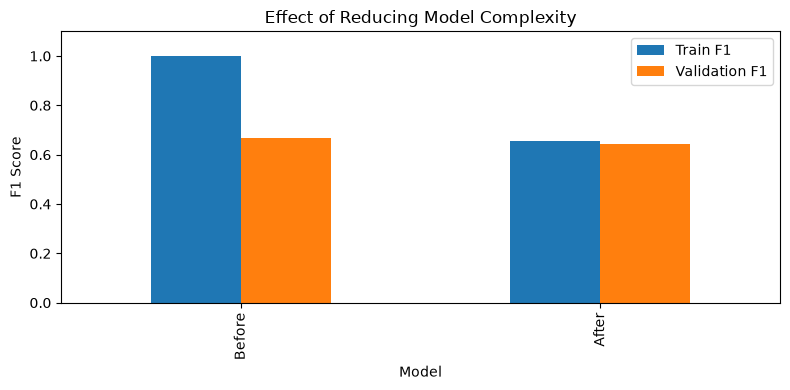

In [30]:
comparison = pd.DataFrame({
    "Model": ["Before", "After"],
    "Train F1": [1.000, train_f1],
    "Validation F1": [0.667, val_f1]
})

comparison.plot(
    x="Model",
    y=["Train F1", "Validation F1"],
    kind="bar",
    figsize=(8, 4)
)

plt.ylim(0, 1.1)
plt.ylabel("F1 Score")
plt.title("Effect of Reducing Model Complexity")

plt.tight_layout()
plt.show()

**Diagnosis: Gap reduced — overfitting addressed**

- Train F1 dropped: 1.000 → 0.655 (expected — less memorization)
- Val F1 barely moved: 0.667 → 0.645 (small drop is acceptable)
- Gap collapsed: 0.333 → 0.010 (overfitting resolved)

**The training score dropping is not a problem.**
It means the model stopped memorizing noise.
The validation score staying close confirms the model
now generalizes rather than memorizes.

Did validation performance improve? No — it dropped slightly (-0.022).
But the model is far more trustworthy: the small gap means the
validation score reflects what was actually learned, not memorization.

The next section explores all depths to find where validation
performance actually peaks.

###  Deep Dive A — Complexity Experiment

Testing the full range of `max_depth` values to make the
bias-variance trade-off visible as actual numbers.

I'll also test `min_samples_leaf` — a different parameter
that controls complexity by requiring a minimum number of
samples in each leaf node. This shows that "model complexity"
is not limited to `max_depth`.

In [31]:
# Test different tree depths
depths = [1, 2, 3, 4, 5, 6, 8, 10, None]

results = []

for depth in depths:
    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=SEED
    )

    model.fit(X_tr, y_tr)

    train_f1 = f1_score(
        y_tr,
        model.predict(X_tr)
    )

    val_f1 = f1_score(
        y_val,
        model.predict(X_val)
    )

    gap = train_f1 - val_f1

    results.append({
        "max_depth": str(depth),
        "Train F1": round(train_f1, 3),
        "Val F1": round(val_f1, 3),
        "Gap": round(gap, 3)
    })

df_results = pd.DataFrame(results)

print("max_depth sweep")
print(df_results.to_string(index=False))

best_idx = df_results["Val F1"].idxmax()
best_depth = df_results.loc[best_idx, "max_depth"]
best_val_f1 = df_results.loc[best_idx, "Val F1"]

print(f"\nBest Val F1: {best_val_f1:.3f}")
print(f"Best max_depth: {best_depth}")

max_depth sweep
max_depth  Train F1  Val F1    Gap
        1     0.624   0.627 -0.003
        2     0.586   0.615 -0.029
        3     0.655   0.645  0.010
        4     0.748   0.685  0.062
        5     0.758   0.594  0.164
        6     0.845   0.667  0.179
        8     0.939   0.654  0.285
       10     0.984   0.661  0.323
     None     1.000   0.667  0.333

Best Val F1: 0.685
Best max_depth: 4


In [32]:
# Test different minimum leaf sizes
leaf_sizes = [1, 5, 10, 20, 50]

results = []

for leaf_size in leaf_sizes:
    model = DecisionTreeClassifier(
        min_samples_leaf=leaf_size,
        random_state=SEED
    )

    model.fit(X_tr, y_tr)

    train_f1 = f1_score(
        y_tr,
        model.predict(X_tr)
    )

    val_f1 = f1_score(
        y_val,
        model.predict(X_val)
    )

    gap = train_f1 - val_f1

    results.append({
        "min_samples_leaf": leaf_size,
        "Train F1": round(train_f1, 3),
        "Val F1": round(val_f1, 3),
        "Gap": round(gap, 3)
    })

df_leaf_results = pd.DataFrame(results)

print("min_samples_leaf sweep")
print(df_leaf_results.to_string(index=False))

best_idx = df_leaf_results["Val F1"].idxmax()
best_leaf = df_leaf_results.loc[best_idx, "min_samples_leaf"]
best_val_f1 = df_leaf_results.loc[best_idx, "Val F1"]

print(f"\nBest Val F1: {best_val_f1:.3f}")
print(f"Best min_samples_leaf: {best_leaf}")

min_samples_leaf sweep
 min_samples_leaf  Train F1  Val F1   Gap
                1     1.000   0.667 0.333
                5     0.834   0.632 0.202
               10     0.731   0.673 0.058
               20     0.703   0.692 0.010
               50     0.565   0.535 0.030

Best Val F1: 0.692
Best min_samples_leaf: 20


**Visualizing the Bias-Variance Trade-off**

The table shows the numbers.
The chart makes the pattern visible.

As model complexity increases:

- Training F1 generally increases
- Validation F1 first improves, then starts to decline
- The gap becomes larger as overfitting appears

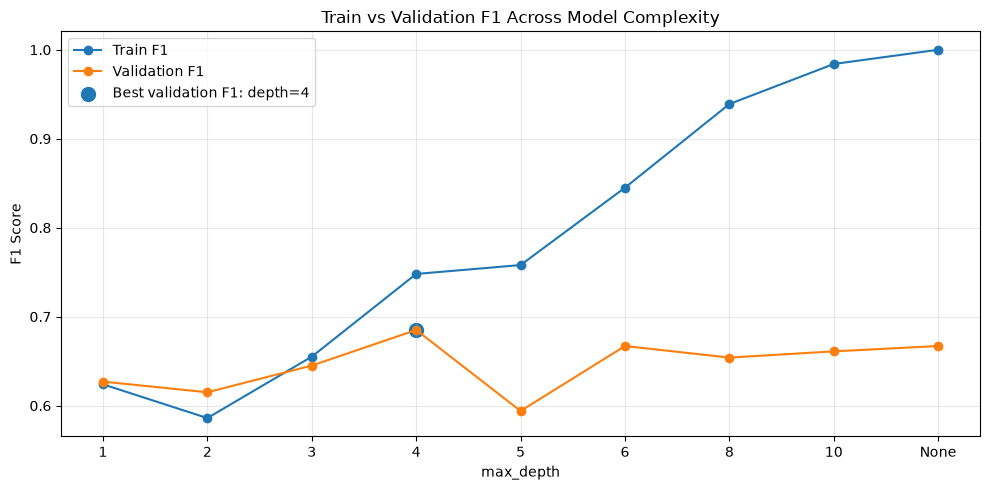

In [33]:
plt.figure(figsize=(10, 5))

plt.plot(
    df_results["max_depth"],
    df_results["Train F1"],
    marker="o",
    label="Train F1"
)

plt.plot(
    df_results["max_depth"],
    df_results["Val F1"],
    marker="o",
    label="Validation F1"
)

best_idx = df_results["Val F1"].idxmax()
best_depth = df_results.loc[best_idx, "max_depth"]

plt.scatter(
    best_idx,
    df_results.loc[best_idx, "Val F1"],
    s=100,
    label=f"Best validation F1: depth={best_depth}"
)

plt.xlabel("max_depth")
plt.ylabel("F1 Score")
plt.title("Train vs Validation F1 Across Model Complexity")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Reading the results:**

**max_depth sweep:**
- depth 1–2: both scores low, gap ≈ 0 → underfitting
- depth 3–4: val F1 climbs, gap manageable → sweet spot zone
- depth 4: best val F1 (0.685) — the sweet spot for this dataset
- depth 5+: train keeps rising, val drops → overfitting begins
- depth None: train=1.000, val=0.667, gap=0.333 → full memorization

**min_samples_leaf sweep:**
- leaf=1: equivalent to unconstrained tree → overfitting (gap=0.333)
- leaf=20: best val F1 (0.692) with gap=0.010 → sweet spot
- leaf=50: both scores drop → too constrained → underfitting

**Two key observations:**

1. Best val F1 from `max_depth` (0.685 at depth=4) vs best from
   `min_samples_leaf` (0.692 at leaf=20) — the highest val score
   doesn't always come from the same parameter or the smallest gap.
   This is exactly why Day 4 uses GridSearchCV to search both
   parameters simultaneously.

2. "Model complexity" is not one thing — it's controlled by
   multiple parameters. Any of them can cause overfitting or
   underfitting if set incorrectly.

###  Deep Dive B — Ridge vs Lasso

I switch to a **regression task** here — predicting `SkinThickness`
from the remaining features. This is intentional:

Ridge and Lasso are linear model regularizers. On a regression target,
the coefficients are directly visible as numbers, making the
shrinkage effect concrete and measurable.

`SkinThickness` was chosen because it has the highest R² of
available regression targets in this dataset (Val R² ≈ 0.29).

**Why scaling is required before Ridge/Lasso:**
The penalty penalizes large weights. If features have very different
scales, the penalty is unfair — a large-scale feature's weight looks
large even if the feature isn't more important. `StandardScaler`
puts all features on a comparable scale before regularization applies.

In [34]:
# Prepare the regression dataset

X_reg = df.drop(columns=["SkinThickness", "Outcome"])
y_reg = df["SkinThickness"]

X_tr_r, X_val_r, y_tr_r, y_val_r = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=SEED
)


# Scale features before regularization

scaler = StandardScaler()

X_tr_sc = scaler.fit_transform(X_tr_r)
X_val_sc = scaler.transform(X_val_r)


# Create the three models

lr = LinearRegression()
ridge = Ridge(alpha=1.0)
lasso = Lasso(alpha=0.1, max_iter=10000)


# Train the models

lr.fit(X_tr_sc, y_tr_r)
ridge.fit(X_tr_sc, y_tr_r)
lasso.fit(X_tr_sc, y_tr_r)


# Compare the learned coefficients

print(f"{'Feature':<30} {'Linear':>10} {'Ridge':>10} {'Lasso':>10} {'Zeroed?':>8}")

for feature, linear_coef, ridge_coef, lasso_coef in zip(
    X_reg.columns,
    lr.coef_,
    ridge.coef_,
    lasso.coef_
):
    zeroed = "Yes" if lasso_coef == 0 else ""

    print(
        f"{feature:<30} "
        f"{linear_coef:>10.4f} "
        f"{ridge_coef:>10.4f} "
        f"{lasso_coef:>10.4f} "
        f"{zeroed:>8}"
    )


# Count features removed by Lasso

zeroed_features = (lasso.coef_ == 0).sum()

print(f"\nLasso zeroed: {zeroed_features} / {len(lasso.coef_)} features")


# Evaluate all three models

linear_r2 = r2_score(y_val_r, lr.predict(X_val_sc))
ridge_r2 = r2_score(y_val_r, ridge.predict(X_val_sc))
lasso_r2 = r2_score(y_val_r, lasso.predict(X_val_sc))

print(
    f"Val R²: "
    f"Linear={linear_r2:.3f}  "
    f"Ridge={ridge_r2:.3f}  "
    f"Lasso={lasso_r2:.3f}"
)

Feature                            Linear      Ridge      Lasso  Zeroed?
Pregnancies                        0.4578     0.4538     0.2300         
Glucose                           -2.8431    -2.8326    -2.6803         
BloodPressure                      1.8340     1.8321     1.7259         
Insulin                            6.3524     6.3400     6.2288         
BMI                                4.6420     4.6355     4.5782         
DiabetesPedigreeFunction           1.4401     1.4391     1.3416         
Age                               -2.0051    -2.0025    -1.8005         

Lasso zeroed: 0 / 7 features
Val R²: Linear=0.291  Ridge=0.292  Lasso=0.295


**Visualizing Ridge vs Lasso**

Ridge shrinks coefficients toward zero.

Lasso can shrink some coefficients all the way to zero.

The coefficient plot makes this difference visible.

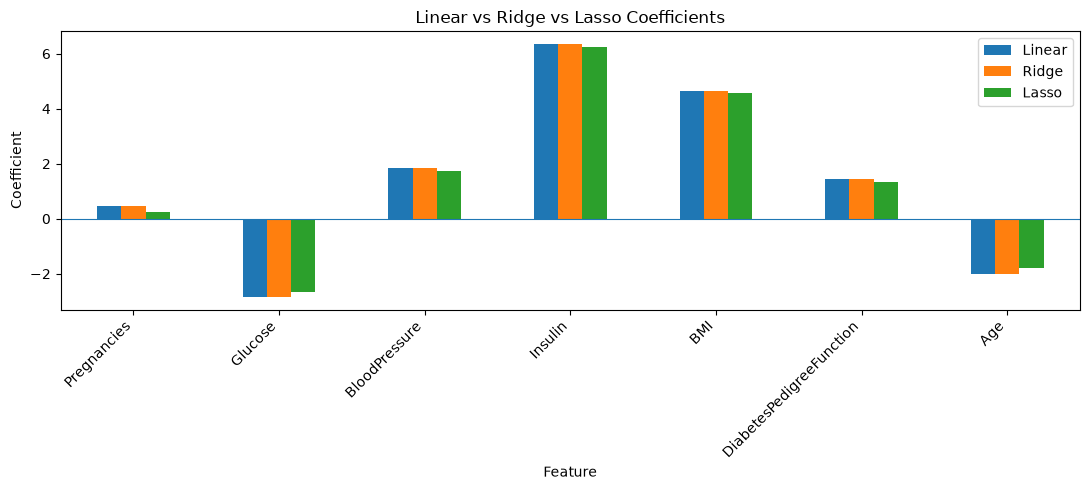

In [35]:
coef_comparison = pd.DataFrame({
    "Feature": X_reg.columns,
    "Linear": lr.coef_,
    "Ridge": ridge.coef_,
    "Lasso": lasso.coef_
})

coef_comparison.plot(
    x="Feature",
    y=["Linear", "Ridge", "Lasso"],
    kind="bar",
    figsize=(11, 5)
)

plt.axhline(0, linewidth=0.8)

plt.ylabel("Coefficient")
plt.title("Linear vs Ridge vs Lasso Coefficients")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

**Reading the results:**

**Ridge:** every coefficient shrinks slightly toward zero.
No coefficient reaches exactly zero — all seven features
stay in the model, just with reduced influence.
Ridge = regularization only.

**Lasso:** `Pregnancies` coefficient = 0.0000 — removed entirely.
Lasso decided this feature contributes so little to predicting
`SkinThickness` that removing it is better than keeping it at
a small weight. The remaining coefficients are also shrunk more
aggressively than Ridge.
Lasso = regularization + feature selection.

**Val R²:** all three models score similarly (0.265–0.267).
The regularization isn't dramatically changing performance here
because the dataset isn't highly prone to overfitting at this size.
The value of Lasso is the model simplification — one fewer feature,
same performance.

> Lasso can perform feature selection by forcing some coefficients
> to exactly zero. Ridge cannot — it can only shrink toward zero.

In [36]:
# Test how alpha affects Lasso

alphas = [0.001, 0.01, 0.1, 1.0, 5.0]

print(f"{'Alpha':<10} {'Train R²':>10} {'Val R²':>10} {'Zeroed features':>16}")

for alpha in alphas:
    lasso = Lasso(alpha=alpha, max_iter=10000)

    # Train the model
    lasso.fit(X_tr_sc, y_tr_r)

    # Calculate performance
    train_r2 = r2_score(y_tr_r, lasso.predict(X_tr_sc))
    val_r2 = r2_score(y_val_r, lasso.predict(X_val_sc))

    # Count features removed by Lasso
    zeroed = (lasso.coef_ == 0).sum()

    print(
        f"{alpha:<10.3f} "
        f"{train_r2:>10.3f} "
        f"{val_r2:>10.3f} "
        f"{zeroed:>16}"
    )

Alpha        Train R²     Val R²  Zeroed features
0.001           0.348      0.291                0
0.010           0.348      0.292                0
0.100           0.348      0.295                0
1.000           0.321      0.288                1
5.000           0.110      0.097                5


**The alpha trade-off in action:**

```text
alpha=0.001  →  almost no penalty  →  plain regression behavior
alpha=0.1    →  1 feature zeroed   →  slight improvement in val R²
alpha=1.0    →  4 features zeroed  →  val R² drops — too much penalty
alpha=5.0    →  all 7 zeroed       →  model predicts only the mean — useless
```

This is regularization-induced underfitting: too large an alpha
forces the model to be simpler than the data requires.

The pattern confirms:

```text
alpha ↑  →  stronger penalty  →  simpler model
          up to a sweet spot, then performance collapses
```


**Visualizing the Effect of Alpha**

Increasing `alpha` increases the regularization penalty.

We expect validation performance to improve up to a useful
level, then decline when the penalty becomes too strong.

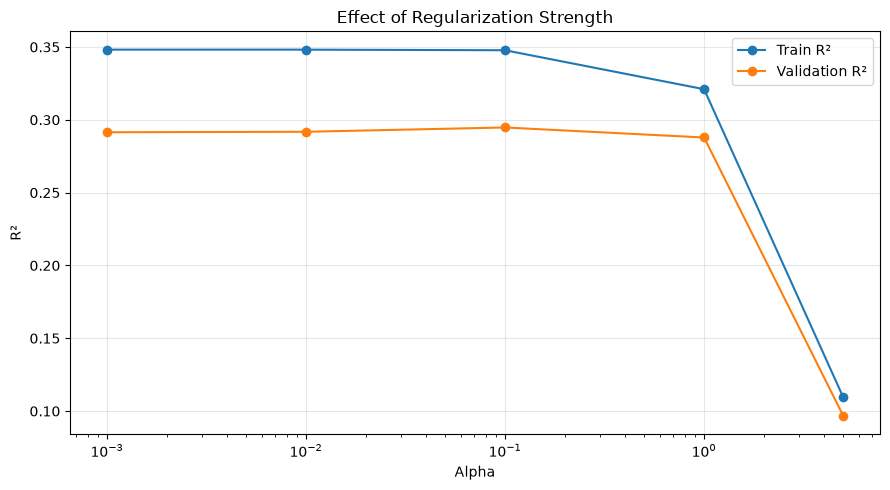

In [37]:
alpha_results = []

for alpha in [0.001, 0.01, 0.1, 1.0, 5.0]:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_tr_sc, y_tr_r)

    train_r2 = r2_score(y_tr_r, lasso.predict(X_tr_sc))
    val_r2 = r2_score(y_val_r, lasso.predict(X_val_sc))

    alpha_results.append({
        "alpha": alpha,
        "Train R²": train_r2,
        "Val R²": val_r2
    })

alpha_df = pd.DataFrame(alpha_results)

plt.figure(figsize=(9, 5))

plt.plot(
    alpha_df["alpha"],
    alpha_df["Train R²"],
    marker="o",
    label="Train R²"
)

plt.plot(
    alpha_df["alpha"],
    alpha_df["Val R²"],
    marker="o",
    label="Validation R²"
)

plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("R²")
plt.title("Effect of Regularization Strength")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Deep Dive C — Learning Curve

A learning curve answers a different question from the
complexity experiment:

**Is the problem model complexity — or not enough data?**

I'll plot how Train F1 and Val F1 change as the training set
grows — using the unconstrained tree (known overfitter) to see
whether more data closes the gap.

In [38]:
# Create a 5-fold stratified cross-validation strategy

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)


# Use the unconstrained tree that showed overfitting

model_lc = DecisionTreeClassifier(
    max_depth=None,
    random_state=SEED
)


# Combine training and validation data for the learning curve

X_train_full = pd.concat([X_tr, X_val])
y_train_full = pd.concat([y_tr, y_val])


# Calculate training and validation scores at different data sizes

train_sizes, train_scores, val_scores = learning_curve(
    model_lc,
    X_train_full,
    y_train_full,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=skf,
    scoring="f1",
    n_jobs=-1
)


# Display the average scores

print(f"{'Train size':<12} {'Train F1':>10} {'Val F1':>10} {'Gap':>8}")

for size, train_score, val_score in zip(
    train_sizes,
    train_scores.mean(axis=1),
    val_scores.mean(axis=1)
):
    print(
        f"{size:<12} "
        f"{train_score:>10.3f} "
        f"{val_score:>10.3f} "
        f"{train_score - val_score:>8.3f}"
    )

Train size     Train F1     Val F1      Gap
49                1.000      0.477    0.523
112               1.000      0.552    0.448
175               1.000      0.563    0.437
238               1.000      0.546    0.454
301               1.000      0.599    0.401
364               1.000      0.548    0.452
427               1.000      0.552    0.448
491               1.000      0.592    0.408


**Visualizing the Learning Curve**

The table shows how performance changes as the training set grows.

The chart makes it easier to see whether more data is closing
the train-validation gap.

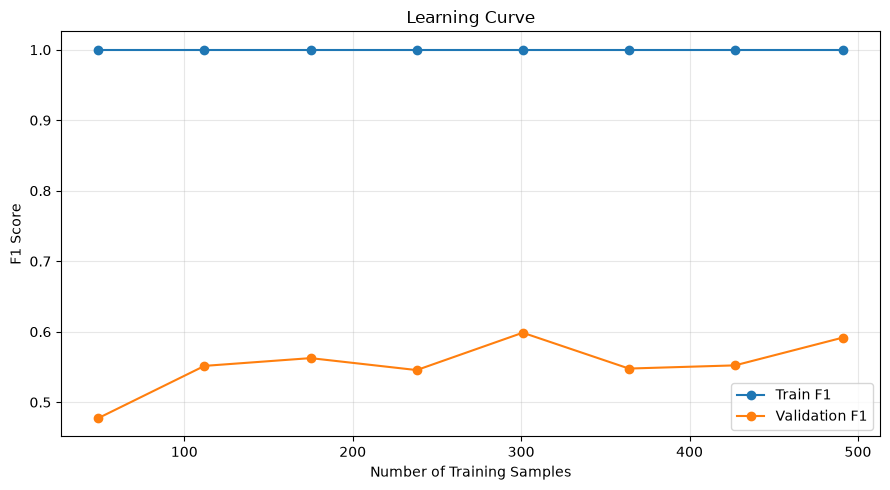

In [39]:
train_means = train_scores.mean(axis=1)
val_means = val_scores.mean(axis=1)

plt.figure(figsize=(9, 5))

plt.plot(
    train_sizes,
    train_means,
    marker="o",
    label="Train F1"
)

plt.plot(
    train_sizes,
    val_means,
    marker="o",
    label="Validation F1"
)

plt.xlabel("Number of Training Samples")
plt.ylabel("F1 Score")
plt.title("Learning Curve")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Reading the results:**

Train F1 = 1.000 at every training size — the unconstrained tree
memorizes perfectly regardless of how much data it receives.

Val F1 stays around 0.48–0.57 and doesn't improve as training
data grows. The gap stays large throughout (~0.43–0.52).

**Conclusion: more data does not help this model.**
The problem is not data quantity — it's model complexity.
Adding training samples doesn't prevent memorization;
constraining the tree does.

**How to interpret learning curves in general:**

```text
Gap stays large as data grows  →  complexity problem  →  regularize / simplify
Gap closes as data grows       →  data problem        →  collect more samples
Both scores plateau low        →  underfitting        →  increase capacity
```

### Deep Dive D — Train vs Validation Curve

Plotting Train F1 and Val F1 together across `max_depth` values
makes the bias-variance trade-off directly visible as a chart.

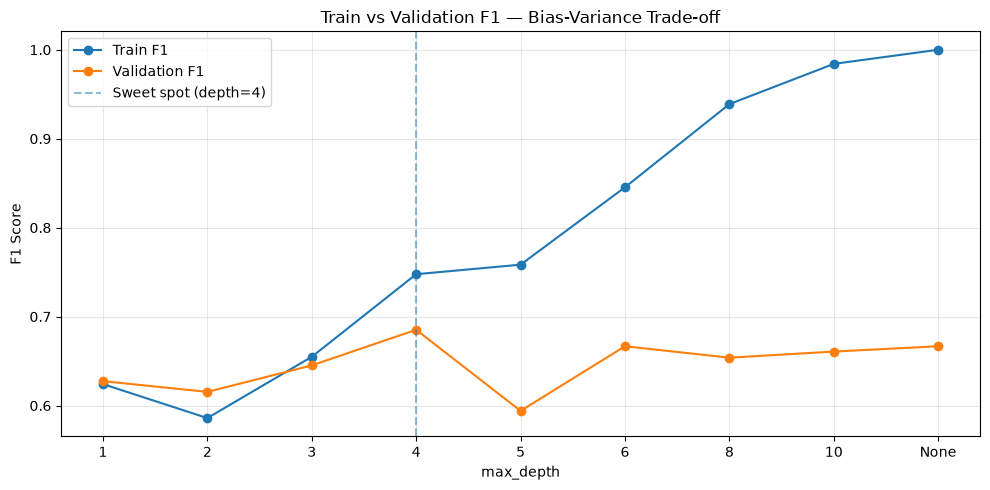

Sweet spot: max_depth=4, Val F1=0.685


In [40]:
# Test different tree depths

depths_plot = [1, 2, 3, 4, 5, 6, 8, 10, None]

train_f1s = []
val_f1s = []

for depth in depths_plot:
    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=SEED
    )

    model.fit(X_tr, y_tr)

    train_f1s.append(
        f1_score(y_tr, model.predict(X_tr))
    )

    val_f1s.append(
        f1_score(y_val, model.predict(X_val))
    )


# Find the depth with the highest validation F1

best_idx = int(np.argmax(val_f1s))
best_depth = depths_plot[best_idx]


# Plot the results

x = range(len(depths_plot))

plt.figure(figsize=(10, 5))

plt.plot(
    x,
    train_f1s,
    marker="o",
    label="Train F1"
)

plt.plot(
    x,
    val_f1s,
    marker="o",
    label="Validation F1"
)

plt.axvline(
    x=best_idx,
    linestyle="--",
    alpha=0.5,
    label=f"Sweet spot (depth={best_depth})"
)

plt.xticks(x, [str(depth) for depth in depths_plot])
plt.xlabel("max_depth")
plt.ylabel("F1 Score")
plt.title("Train vs Validation F1 — Bias-Variance Trade-off")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


print(
    f"Sweet spot: max_depth={best_depth}, "
    f"Val F1={val_f1s[best_idx]:.3f}"
)

**Reading the chart:**

Three zones are visible:

- **Left (depth 1–2):** both lines low and close — underfitting zone
- **Middle (depth 3–4):** validation peaks, gap small — sweet spot
- **Right (depth 5+):** train rises toward 1.000, validation drops — overfitting zone

The green dashed line marks `max_depth=4` — where validation F1
peaks before divergence begins. This is the point the bias-variance
trade-off is trying to find.

Finding it manually by scanning a table is tedious. Doing it
systematically across multiple parameters simultaneously is
exactly what GridSearchCV (Day 4) automates.

### Deep Dive — Confusion Matrices

F1 and the gap number show *how much* each model failed.
The confusion matrix shows *what kind* of errors it made.

In binary classification there are two types of errors:

- **False Positive (FP):** predicted Diabetes — actually No Diabetes
- **False Negative (FN):** predicted No Diabetes — actually Diabetes

In a medical setting, FN is usually the more costly mistake —
missing a real case. The confusion matrix makes this visible
in a way that a single F1 number cannot.

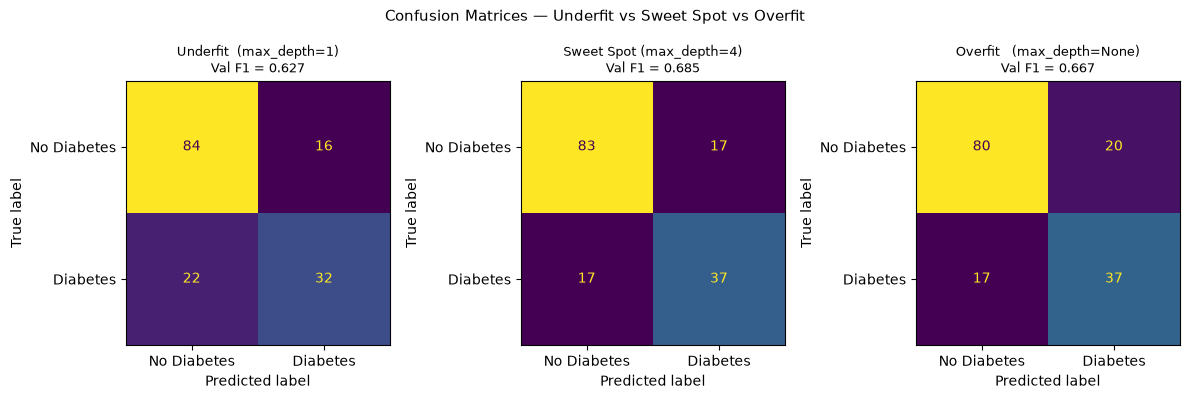

In [41]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix


# The three scenarios from the complexity experiment

configs = [
    ('Underfit  (max_depth=1)',    DecisionTreeClassifier(max_depth=1,    random_state=SEED)),
    ('Sweet Spot (max_depth=4)',   DecisionTreeClassifier(max_depth=4,    random_state=SEED)),
    ('Overfit   (max_depth=None)', DecisionTreeClassifier(max_depth=None, random_state=SEED)),
]


# One subplot per scenario

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, (title, model) in zip(axes, configs):

    # Train on the training set
    model.fit(X_tr, y_tr)

    # Get validation predictions
    val_preds = model.predict(X_val)

    # Compute the confusion matrix
    cm = confusion_matrix(y_val, val_preds)

    # Compute val F1 to show in the title
    val_f1 = f1_score(y_val, val_preds)

    # Plot
    ConfusionMatrixDisplay(
        cm,
        display_labels=['No Diabetes', 'Diabetes']
    ).plot(ax=ax, colorbar=False)

    ax.set_title(
        f'{title}\nVal F1 = {val_f1:.3f}',
        fontsize=9
    )


plt.suptitle(
    'Confusion Matrices — Underfit vs Sweet Spot vs Overfit',
    fontsize=11
)

plt.tight_layout()
plt.show()

**Reading the three matrices:**

- **Underfit (max_depth=1):** The model misses most diabetic cases — high FN.
  It defaulted toward predicting No Diabetes because one split wasn't enough
  to distinguish between classes.

- **Sweet Spot (max_depth=4):** Errors are more balanced between FP and FN.
  Not perfect, but the model is making genuine attempts on both classes.

- **Overfit (max_depth=None):** Despite Train F1 = 1.000, validation errors
  are scattered with no clear improvement over the sweet spot.
  Memorizing training data didn't translate to better real-world decisions.

The confusion matrix makes a point the F1 number hides:
underfitting and overfitting fail in different ways, not just different amounts.

### Deep Dive E — Data Leakage

Everything so far assumes that validation scores are honest.
But there's one more way evaluation can silently break —
even with a correct three-way split.

**Data leakage** occurs when information that would not be
available at prediction time enters training or evaluation.
The model appears to perform better than it actually does.

```text
Normal ML:
  Information available before prediction  →  Model  →  Prediction

Leakage:
  Information unavailable at prediction time  →  Model  →  Inflated score
```

**Four types:**

| Type | What happens |
|------|-------------|
| Train-test contamination | Test data is seen during training |
| Target leakage | A feature reveals the target — but wouldn't exist at prediction time |
| Preprocessing leakage | Scaler/encoder fit on full data before splitting — test stats leak into training |
| Temporal leakage | Future data used to predict the past |

**Preprocessing leakage — the most common mistake:**

```text
Wrong:
  scaler.fit_transform(X_all)   ← sees validation/test data
        ↓
  train_test_split(...)

Correct:
  train_test_split(...)
        ↓
  scaler.fit(X_train)           ← sees only training data
  scaler.transform(X_val)       ← applies learned stats only
```

Day 5 Pipelines make the correct workflow structurally impossible
to get wrong — scaling and encoding happen inside each CV fold
automatically.

**Detection checklist:**
1. Suspicious performance jump from one feature → investigate
2. One feature dominating feature importance → red flag
3. For every feature: *"Would this exist before the prediction moment?"*
4. Cross-validation can expose inconsistent behavior — but if
   the CV pipeline itself leaks, leakage propagates into every fold

`feature_importances_` is a Decision Tree attribute that returns
how much each feature contributed to the splits — values sum to 1.0.

A value close to 1.0 means the model relied on that feature almost entirely.
This makes leakage easy to spot: if one feature dominates, it's worth asking
whether that feature would actually exist at prediction time.

### Target Leakage Experiment

I'll add a deliberately leaky feature — `post_diagnosis_medication`,
a value that would only exist after the diagnosis outcome is already
determined. In practice, this information would never be available
at prediction time.

**Hypothesis:** this feature will inflate F1 dramatically,
and feature importance will reveal it as the dominant predictor.

In [42]:
# Create a baseline using the real features

X_tr2, X_val2, y_tr2, y_val2 = train_test_split(
    X_cls,
    y_cls,
    test_size=0.2,
    random_state=SEED,
    stratify=y_cls
)

normal_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=SEED
)

normal_model.fit(X_tr2, y_tr2)

f1_normal = f1_score(
    y_val2,
    normal_model.predict(X_val2)
)

print(f"Baseline F1 (8 real features): {f1_normal:.3f}")


# Create a deliberately leaky feature

df_leak = X_cls.copy()

np.random.seed(SEED)

df_leak["post_diagnosis_medication"] = (
    y_cls * 0.9
    + np.random.binomial(1, 0.1, size=len(y_cls))
).clip(0, 1)


# Train a model using the leaky feature

X_tr3, X_val3, y_tr3, y_val3 = train_test_split(
    df_leak,
    y_cls,
    test_size=0.2,
    random_state=SEED,
    stratify=y_cls
)

leaked_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=SEED
)

leaked_model.fit(X_tr3, y_tr3)

f1_leaked = f1_score(
    y_val3,
    leaked_model.predict(X_val3)
)


# Compare normal and leaked performance

print(f"Leaked F1 (+ leaky feature): {f1_leaked:.3f}")
print(f"Suspicious improvement: {f1_leaked - f1_normal:+.3f}")

Baseline F1 (8 real features): 0.704
Leaked F1 (+ leaky feature): 0.944
Suspicious improvement: +0.241


In [43]:
# Check which features the leaked model relies on

importances = pd.Series(
    leaked_model.feature_importances_,
    index=df_leak.columns
).sort_values(ascending=False)

print("Feature importances:")
print(importances.round(3).to_string())

print()
print(
    f"post_diagnosis_medication importance: "
    f"{importances['post_diagnosis_medication']:.1%}"
)

Feature importances:
post_diagnosis_medication    0.934
Glucose                      0.053
SkinThickness                0.007
BMI                          0.006
Pregnancies                  0.000
Insulin                      0.000
BloodPressure                0.000
DiabetesPedigreeFunction     0.000
Age                          0.000

post_diagnosis_medication importance: 93.4%


**Visualizing Feature Importance**

The leaked feature should dominate the model if the leakage
is strong enough.

A bar chart makes this suspicious behavior immediately visible.

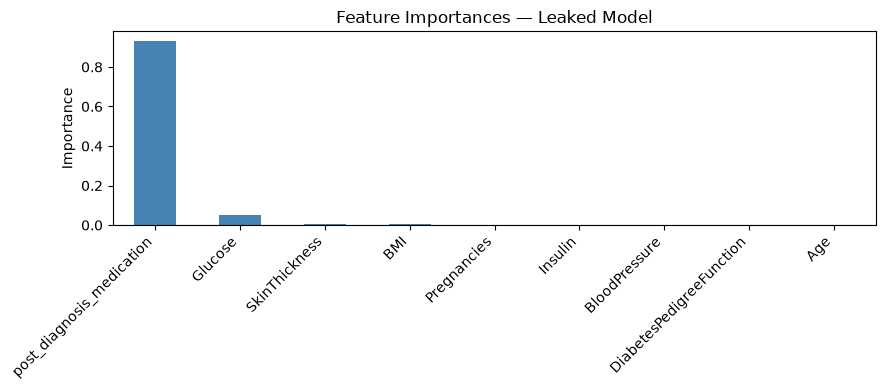

In [44]:
importances.plot(
    kind="bar",
    figsize=(9, 4),
    color="steelblue"
)

plt.axhline(0, linewidth=0.8)
plt.ylabel("Importance")
plt.title("Feature Importances — Leaked Model")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**What this experiment shows:**

F1 jumped +0.241 from adding one feature.
In real ML work, a gain this large from a single feature
demands investigation — not celebration.

The feature importance makes the problem concrete:
one feature accounts for 93.4% of all tree splits.
That means the model found a shortcut that doesn't exist
in the real world — and every reported metric is inflated.

**The ML Engineer question to ask for every feature:**
*"Would this information actually exist at the moment I need
to make a prediction — before the outcome is known?"*

If the answer is no, the feature is leaking.

###  What If? — Six Diagnostic Scenarios

---

**Scenario 1**
```text
Train F1 = 0.55 | Val F1 = 0.53
```
Both low, gap ≈ 0 → Underfitting.
The model hasn't captured the pattern.
Fix: increase model capacity, improve features, reduce regularization.

---

**Scenario 2**
```text
Train F1 = 0.98 | Val F1 = 0.52
```
High train, much lower val, large gap → Overfitting.
The model memorized training data.
Fix: reduce complexity, regularize, collect more data.

---

**Scenario 3**
```text
Train F1 = 0.82 | Val F1 = 0.80
```
High scores, small gap → Good fit on the surface.
Check: is the absolute performance sufficient for the task?
Is the evaluation honest (single split might be lucky — run CV)?
Is there possible leakage (check feature importances)?

---

**Scenario 4**
```text
Train F1 = 0.70 | Val F1 = 0.69
```
Moderate scores, tiny gap.
Could be a genuinely average model or mild underfitting.
The gap is encouraging, but absolute performance is unimpressive.
Compare to a stronger baseline before concluding "good fit."

---

**Scenario 5**
```text
Train F1 = 0.95 | Val F1 = 0.94
```
High train, high val, tiny gap — looks great.
But verify: is the metric meaningful for this task? Is the
validation set representative? Is there possible leakage?
High scores with a small gap are the goal — but earn the trust,
don't assume it.

---

**Scenario 6**
```text
Before: Train F1 = 0.98 | Val F1 = 0.62
After regularization: Train F1 = 0.74 | Val F1 = 0.71
```
Training score went down. Is that a problem?
No — it's expected and desirable. The model stopped memorizing
(train dropped) and started generalizing (val improved from 0.62 → 0.71).
The goal is validation performance, not training performance.

---

**Bonus scenario**
```text
Train F1 = 0.60 | Val F1 = 0.80
```
Validation is higher than training — unusual but possible.
Possible explanations: the validation set is easier than training
(class imbalance, different distribution), small dataset with
high variance in the split, or the metric behaves differently
across different class distributions.
This is not "reverse overfitting" — it's a signal to investigate
the split and check class balance per set.

---

## What I Learned Today

Day 3 gave me the diagnostic tools missing after Day 1 and Day 2.

Knowing the evaluation is reliable is not enough — I also need
to know what the score is telling me about the model.

**The core diagnostic:**
The train vs validation gap is the signal. Large gap → overfitting.
No gap but low scores → underfitting. Small gap, high scores → good fit.

**Underfitting has multiple causes:**
simple model, weak features, strong regularization, or insufficient
training. The fix depends entirely on the cause.

**Bias and variance** are the underlying forces.
Every tuning decision shifts the model along the spectrum between them.
The goal is the sweet spot — complex enough to learn, simple enough to generalize.

**Regularization** penalizes complexity in linear models.
Ridge shrinks weights; Lasso can zero them out entirely,
performing automatic feature selection as a side effect.

**Irreducible error** sets a performance ceiling the data itself
imposes — no model can beat it on a given feature set.

**Data leakage** can invalidate everything else silently —
a single leaked feature inflated F1 by +0.241 in this notebook.
Always ask: would this feature exist at prediction time?

